In [1]:
!pip install "numpy==2.0.2" pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 96.1 MB/s eta 0:00:00


In [2]:
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

from tqdm import tqdm

gpu_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cpu_device = torch.device("cpu")

print("GPU device:", gpu_device)
print("CPU device:", cpu_device)

def set_seed(seed_value=42):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

GPU device: cuda
CPU device: cpu


In [3]:
txt_files = glob.glob('/kaggle/input/**/train.txt', recursive=True)
if len(txt_files) > 0:
    DATA_DIR = txt_files[0].rsplit('/', 1)[0]
    print(f" Automatically found dataset at: {DATA_DIR}")
else:
    # Fallback for local testing
    DATA_DIR = "./SingleLabelEmotionDataset" 
    print(f" Using fallback directory: {DATA_DIR}")
TRAIN_FILE = f"{DATA_DIR}/train.txt"
TEST_FILE  = f"{DATA_DIR}/test.txt"
# 2. Setup Labels
EMOTION_COLS = ['happy', 'surprise', 'sad', 'disgust', 'angry', 'fear']
EMOTION_TO_ID = {emo: i for i, emo in enumerate(EMOTION_COLS)}
NUM_LABELS   = len(EMOTION_COLS)
# 3. Loader Function
def load_txt_data(filepath):
    texts, labels = [], []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(maxsplit=1)
            if len(parts) == 2 and parts[0] in EMOTION_TO_ID:
                labels.append(EMOTION_TO_ID[parts[0]])
                texts.append(parts[1])
    return pd.DataFrame({'Data': texts, 'Label': labels})
# 4. Load Data
df_train_full = load_txt_data(TRAIN_FILE)
df_te         = load_txt_data(TEST_FILE)
df_tr, df_vl = train_test_split(
    df_train_full, test_size=0.15, random_state=42, stratify=df_train_full['Label']
)
df_tr = df_tr.reset_index(drop=True)
df_vl = df_vl.reset_index(drop=True)
df_te = df_te.reset_index(drop=True)
print("Train:", df_tr.shape, "| Valid:", df_vl.shape, "| Test:", df_te.shape)
print(f"NUM_LABELS = {NUM_LABELS}  ->  {EMOTION_COLS}")

 Automatically found dataset at: /kaggle/input/datasets/sayanmanik2005/singlelabelemotiondatasetbangla/SingleLabelEmotionDataset
Train: (3995, 2) | Valid: (705, 2) | Test: (940, 2)
NUM_LABELS = 6  ->  ['happy', 'surprise', 'sad', 'disgust', 'angry', 'fear']


In [4]:
class SingleLabelEmotionDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.data      = df
        self.tokenizer = tokenizer
        self.max_len   = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        encoding = self.tokenizer(
            str(row['Data']),
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        label = torch.tensor(row['Label'], dtype=torch.long)
        return (
            encoding['input_ids'].squeeze(0),       
            encoding['attention_mask'].squeeze(0),  
            label                                   
        )

TEXT_MODEL   = 'ai4bharat/IndicBERTv2-MLM-only'

tokenizer    = AutoTokenizer.from_pretrained(TEXT_MODEL)
text_encoder = AutoModel.from_pretrained(TEXT_MODEL).to(gpu_device)

print("Text encoder loaded on:", next(text_encoder.parameters()).device)

config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.75M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ai4bharat/IndicBERTv2-MLM-only
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Text encoder loaded on: cuda:0


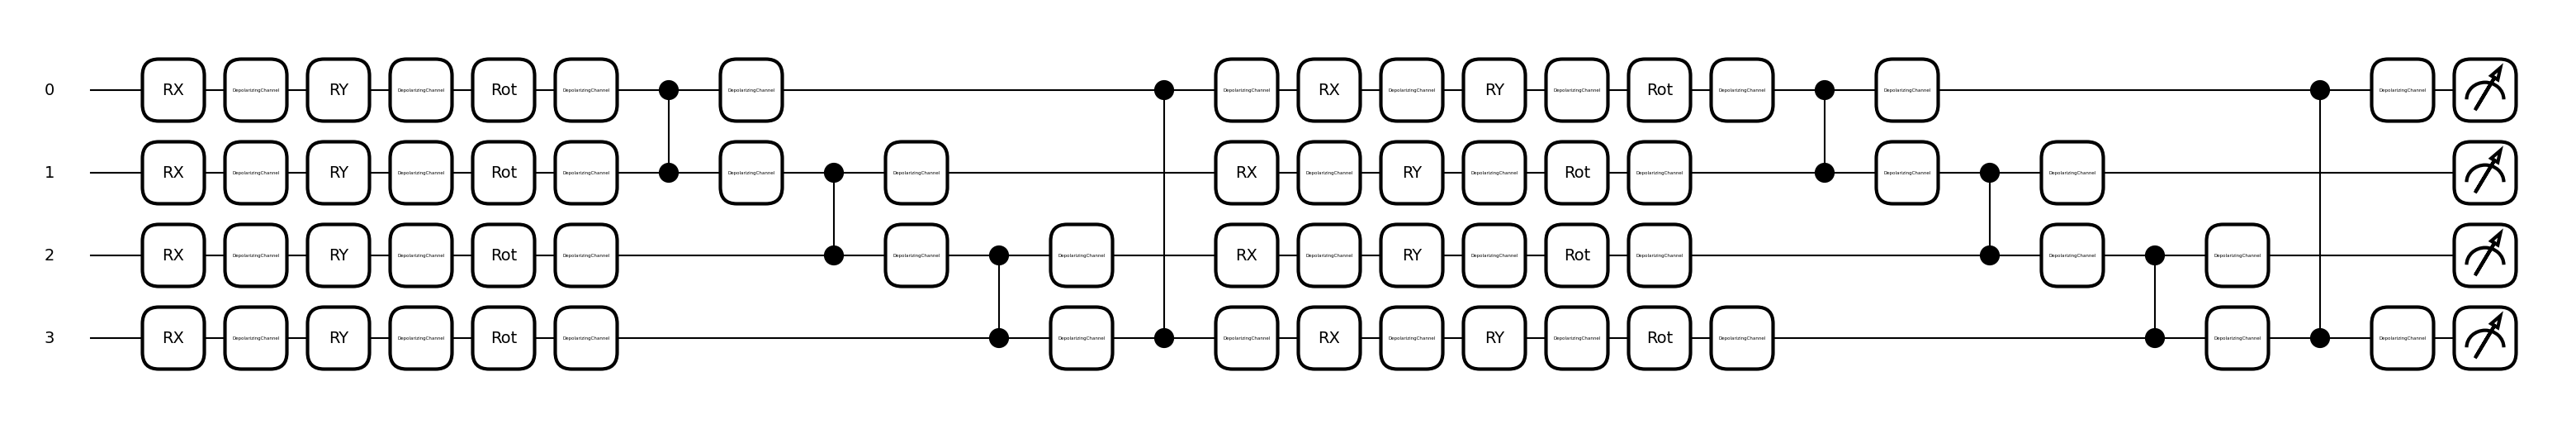

In [5]:
N_QUBITS   = 4 
N_Q_LAYERS = 1
P_NOISE    = 0.05 

dev = qml.device("default.mixed", wires=N_QUBITS)

def encode(inputs, input_phi, input_scale):
    for q in range(N_QUBITS):
        c, s = torch.cos(input_phi[q]), torch.sin(input_phi[q])
        i0, i1 = 2 * q, 2 * q + 1
        x_rx = input_scale[q] * (c * inputs[i0] - s * inputs[i1])
        x_ry = input_scale[q] * (s * inputs[i0] + c * inputs[i1])
        
        qml.RX(x_rx, wires=q)
        qml.DepolarizingChannel(P_NOISE, wires=q)
        qml.RY(x_ry, wires=q)
        qml.DepolarizingChannel(P_NOISE, wires=q)

def ansatz_block(w):
    for q in range(N_QUBITS):
        qml.Rot(w[q, 0], w[q, 1], w[q, 2], wires=q)
        qml.DepolarizingChannel(P_NOISE, wires=q)
    for q in range(N_QUBITS):
        ctrl = q
        targ = (q + 1) % N_QUBITS
        qml.CZ(wires=[ctrl, targ])
        qml.DepolarizingChannel(P_NOISE, wires=ctrl)
        qml.DepolarizingChannel(P_NOISE, wires=targ)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, input_phi, input_scale, weights):
    encode(inputs, input_phi, input_scale)
    ansatz_block(weights)
    encode(inputs, input_phi, input_scale)
    ansatz_block(weights)
    return [qml.expval(qml.PauliZ(q)) for q in range(N_QUBITS)] + [qml.expval(qml.PauliX(q)) for q in range(N_QUBITS)]

class VQCParams(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_phi   = nn.Parameter(torch.zeros(N_QUBITS))
        self.input_scale = nn.Parameter(torch.full((N_QUBITS,), 0.5))
        self.weights     = nn.Parameter(torch.randn(N_Q_LAYERS, N_QUBITS, 3) * 0.1)
# --- Plotting the Circuit ---
dummy_inputs  = torch.randn(2 * N_QUBITS)
dummy_phi     = torch.zeros(N_QUBITS)
dummy_scale   = torch.full((N_QUBITS,), 0.5)
dummy_weights = torch.randn(N_QUBITS, 3) 

fig, ax = qml.draw_mpl(quantum_circuit)(dummy_inputs, dummy_phi, dummy_scale, dummy_weights)
plt.show()

class QuantumBottleneck(nn.Module):
    def __init__(self):
        super().__init__()
        self.vqc = VQCParams()

    def forward(self, x):
        outputs = []
        x_cpu = x.cpu() if x.is_cuda else x
        
        # Safely project quantum parameters to CPU for PennyLane.
        phi_cpu   = self.vqc.input_phi.cpu()
        scale_cpu = self.vqc.input_scale.cpu()
        w_cpu     = self.vqc.weights[0].cpu()

        for i in range(x_cpu.shape[0]):
            out = torch.stack(quantum_circuit(x_cpu[i], phi_cpu, scale_cpu, w_cpu))
            outputs.append(out)
            
        return torch.stack(outputs).to(x.device).float()

class QuantumFusionLayer(nn.Module):
    def __init__(self, in_dim=128, q_dim=N_QUBITS): 
        super().__init__()
        self.pre_q   = nn.Linear(in_dim, 2 * q_dim)
        self.quantum = QuantumBottleneck()
        
    def forward(self, x):
        x_q   = torch.tanh(self.pre_q(x))
        q_out = self.quantum(x_q)
        return q_out

class SingleLabelQuantumEmotionClassifier(nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.text_encoder = text_encoder
        self.text_compressed = nn.Sequential(nn.Linear(768, 128))
        self.quantum_fusion = QuantumFusionLayer(in_dim=128, q_dim=N_QUBITS)
        self.classifier = nn.Linear(2 * N_QUBITS, num_labels)

    def forward(self, input_ids, attention_mask):
        text_feat = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state[:, 0, :]                       

        text_compressed = self.text_compressed(text_feat)       
        q_out  = self.quantum_fusion(text_compressed)  
        return self.classifier(F.relu(q_out.float()))



In [6]:
MAX_LEN    = 128
BATCH_SIZE = 16

train_dataset = SingleLabelEmotionDataset(df_tr, tokenizer, MAX_LEN)
val_dataset   = SingleLabelEmotionDataset(df_vl, tokenizer, MAX_LEN)
test_dataset  = SingleLabelEmotionDataset(df_te, tokenizer, MAX_LEN)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, worker_init_fn=seed_worker, generator=g)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, worker_init_fn=seed_worker, generator=g)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, worker_init_fn=seed_worker, generator=g)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

# Fixed the typo here: y=labels_np instead of y_root=labels_np
labels_np = df_tr['Label'].values
cw = compute_class_weight(class_weight='balanced', classes=np.unique(labels_np), y=labels_np)
class_weights = torch.tensor(cw, dtype=torch.float32).to(gpu_device)
print("Class weights for CrossEntropy:", class_weights.cpu().numpy())

Train batches: 250 | Val: 45 | Test: 59
Class weights for CrossEntropy: [0.5222222  1.9583334  0.78333336 1.5666667  0.78333336 2.6111112 ]


In [7]:
def train_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    all_preds, all_gold = [], []

    for input_ids, attn_mask, labels in tqdm(dataloader, desc='Training'):
        input_ids = input_ids.to(gpu_device)
        attn_mask = attn_mask.to(gpu_device)
        labels    = labels.to(gpu_device)

        optimizer.zero_grad()
        logits = model(input_ids, attn_mask)
        loss   = criterion(logits, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        
        preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
        all_preds.extend(preds)
        all_gold.extend(labels.detach().cpu().numpy())

    macro_f1 = f1_score(all_gold, all_preds, average='macro', zero_division=0)
    return total_loss / len(dataloader), macro_f1

def evaluate(model, dataloader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_gold = [], []

    with torch.no_grad():
        for input_ids, attn_mask, labels in dataloader:
            input_ids = input_ids.to(gpu_device)
            attn_mask = attn_mask.to(gpu_device)
            labels    = labels.to(gpu_device)

            logits = model(input_ids, attn_mask)
            loss   = criterion(logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_gold.extend(labels.cpu().numpy())

    base_metrics = {
        'loss'         : total_loss / len(dataloader),
        'macro_f1'     : f1_score(all_gold, all_preds, average='macro', zero_division=0),
        'accuracy'     : accuracy_score(all_gold, all_preds),
        'preds'        : all_preds,
        'gold'         : all_gold,
    }
    return base_metrics

class EarlyStopping:
    def __init__(self, patience=8, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_score = None
        self.counter    = 0
        self.best_state = None

    def step(self, score, model):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter    = 0
            self.best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            return False   
        else:
            self.counter += 1
            return self.counter >= self.patience

    def restore(self, model):
        model.load_state_dict(self.best_state)

In [8]:
model = SingleLabelQuantumEmotionClassifier(num_labels=NUM_LABELS).to(gpu_device)

# The optimizer now automatically includes the quantum weights!
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay = 0.01)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
)

criterion = nn.CrossEntropyLoss(weight=class_weights)
early_stopping = EarlyStopping(patience=8)

print("Model on:", next(model.parameters()).device)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,} | Trainable: {trainable_params:,}")

NUM_EPOCHS = 25 

train_loss_arr, val_loss_arr, val_f1_arr = [], [], []

for epoch in range(NUM_EPOCHS):
    train_loss, train_f1 = train_epoch(model, train_loader, optimizer, criterion)
    val_metrics          = evaluate(model, val_loader, criterion)

    val_loss = val_metrics['loss']
    val_f1   = val_metrics['macro_f1']
    val_acc  = val_metrics['accuracy']

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | Train Macro-F1: {train_f1:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Macro-F1: {val_f1:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    train_loss_arr.append(train_loss)
    val_loss_arr.append(val_loss)
    val_f1_arr.append(val_f1)

    should_stop = early_stopping.step(val_f1, model)
    
    # Save fully packaged model immediately when new best is found
    if early_stopping.counter == 0:
        SAVE_PATH = "/kaggle/working/best_single_label_noisy_vqc2.pth"
        checkpoint = {
            'model_state_dict': early_stopping.best_state,
            'num_labels': NUM_LABELS,
            'emotion_cols': EMOTION_COLS,
            'text_model_name': TEXT_MODEL,
            'max_len': MAX_LEN,
            'n_qubits': N_QUBITS,
            'n_qlayers': N_Q_LAYERS,
            'best_val_macro_f1': early_stopping.best_score
        }
        torch.save(checkpoint, SAVE_PATH)
        print(f"   ->  New best model safely saved to disk!")

    if should_stop:
        print(f"Early stopping triggered at epoch {epoch+1}. Restoring best weights...")
        break

early_stopping.restore(model)
print(f"Best Val Macro-F1 Restored: {early_stopping.best_score:.4f}")

Model on: cuda:0
Total params: 278,140,882 | Trainable: 278,140,882



Training: 100%|██████████| 250/250 [10:11<00:00,  2.45s/it]


Epoch [01/25] | Train Loss: 1.8090 | Train Macro-F1: 0.0932 | Val Loss: 1.7941 | Val Macro-F1: 0.0714 | Val Acc: 0.0879
   ->  New best model safely saved to disk!


Training: 100%|██████████| 250/250 [10:06<00:00,  2.43s/it]


Epoch [02/25] | Train Loss: 1.7878 | Train Macro-F1: 0.1733 | Val Loss: 1.7801 | Val Macro-F1: 0.1867 | Val Acc: 0.2397
   ->  New best model safely saved to disk!


...

Epoch [13/25] | Train Loss: 1.6441 | Train Macro-F1: 0.3110 | Val Loss: 1.7435 | Val Macro-F1: 0.2040 | Val Acc: 0.3064


Training: 100%|██████████| 250/250 [09:13<00:00,  2.22s/it]


Epoch [14/25] | Train Loss: 1.6355 | Train Macro-F1: 0.3093 | Val Loss: 1.7436 | Val Macro-F1: 0.1937 | Val Acc: 0.2766


Training: 100%|██████████| 250/250 [09:12<00:00,  2.21s/it]


Epoch [15/25] | Train Loss: 1.6288 | Train Macro-F1: 0.3113 | Val Loss: 1.7413 | Val Macro-F1: 0.2016 | Val Acc: 0.2993
Early stopping triggered at epoch 15. Restoring best weights...
Best Val Macro-F1 Restored: 0.2083


In [9]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, hamming_loss
from sklearn.preprocessing import label_binarize
import numpy as np

# Load the test metrics
test_metrics = evaluate(model, test_loader, criterion)

gold_labels = test_metrics['gold']
pred_labels = test_metrics['preds']

# Convert single labels (e.g., 2) into multi-label format (e.g., [0,0,1,0,0,0])
gold_bin = label_binarize(gold_labels, classes=range(NUM_LABELS))
pred_bin = label_binarize(pred_labels, classes=range(NUM_LABELS))

# Calculate global metrics
macro_f1    = f1_score(gold_labels, pred_labels, average='macro', zero_division=0)
micro_f1    = f1_score(gold_labels, pred_labels, average='micro', zero_division=0)
weighted_f1 = f1_score(gold_labels, pred_labels, average='weighted', zero_division=0)
h_loss      = hamming_loss(gold_bin, pred_bin)

# Exact Match Ratio (Identical to Accuracy in Single-Label)
emr = accuracy_score(gold_bin, pred_bin)

# Partial Match (Instance-level)
intersection = np.sum(np.logical_and(gold_bin, pred_bin))
pred_sum     = np.sum(pred_bin)
gold_sum     = np.sum(gold_bin)

partial_precision = intersection / pred_sum if pred_sum > 0 else 0
partial_recall    = intersection / gold_sum if gold_sum > 0 else 0

if (partial_precision + partial_recall) > 0:
    partial_f1 = 2 * (partial_precision * partial_recall) / (partial_precision + partial_recall)
else:
    partial_f1 = 0.0

# --- Print the exact format you need ---
print(f"Test Loss        : {test_metrics['loss']:.4f}")
print(f"Test Macro-F1    : {macro_f1:.4f}")
print(f"Test Micro-F1    : {micro_f1:.4f}")
print(f"Test Weighted-F1 : {weighted_f1:.4f}")
print(f"Test Hamming Loss: {h_loss:.4f}\n")

print(f"--- Exact Match ------------------------------")
print(f"Exact Match Ratio : {emr:.4f}")
print(f"Precision         : {emr:.4f}")
print(f"Recall            : {emr:.4f}")
print(f"F1                : {emr:.4f}\n")

print(f"--- Partial Match (instance-level) -----------")
print(f"Precision         : {partial_precision:.4f}")
print(f"Recall            : {partial_recall:.4f}")
print(f"F1                : {partial_f1:.4f}\n")

print("Per-label Classification Report:")
print(classification_report(
    gold_labels, pred_labels,
    target_names=EMOTION_COLS, digits=4, zero_division=0
))

print(f"\n✅ Model was previously saved directly to: /kaggle/working/best_single_label_noisy_vqc2.pth")

Test Loss        : 1.7694
Test Macro-F1    : 0.2009
Test Micro-F1    : 0.2894
Test Weighted-F1 : 0.2403
Test Hamming Loss: 0.2369

--- Exact Match ------------------------------
Exact Match Ratio : 0.2894
Precision         : 0.2894
Recall            : 0.2894
F1                : 0.2894

--- Partial Match (instance-level) -----------
Precision         : 0.2894
Recall            : 0.2894
F1                : 0.2894

Per-label Classification Report:
              precision    recall  f1-score   support

       happy     0.0000    0.0000    0.0000       300
    surprise     0.0000    0.0000    0.0000        80
         sad     0.3887    0.6200    0.4778       200
     disgust     0.0909    0.0100    0.0180       100
       angry     0.6039    0.6250    0.6143       200
        fear     0.0546    0.3667    0.0950        60

    accuracy                         0.2894       940
   macro avg     0.1897    0.2703    0.2009       940
weighted avg     0.2243    0.2894    0.2403       940


✅ Model